<a href="https://colab.research.google.com/github/joannyvitorinounb-design/Controle-Estat-stico-de-Processos-2026.1/blob/main/MVP_CEP_vers%C3%A3o_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP - Produto Mínimo Viável**

**Tema: Avaliação da qualidade de um processo de usinagem industrial utilizando Controle Estatístico de Processos (CEP) e técnicas de Machine Learning.**

**Joanny Vitória Vitorino Duarte 222014302**

**DEFINIÇÃO DO PROBLEMA**

O processo de usinagem industrial é caracterizado pela operação contínua de máquinas-ferramenta, nas quais variáveis operacionais como temperatura, torque, velocidade de rotação e desgaste da ferramenta influenciam diretamente a qualidade do produto final e a ocorrência de falhas.

O principal problema abordado neste estudo é a identificação de instabilidades operacionais e padrões associados à ocorrência de falhas no processo produtivo.

***Objetivo***

Avaliar a qualidade do processo de usinagem por meio de técnicas de Controle Estatístico de Processos (CEP) e desenvolver um modelo de Machine Learning capaz de identificar condições operacionais associadas à ocorrência de falhas.

***Hipóteses***

- Variações anormais nas variáveis operacionais estão associadas à ocorrência de falhas
- O processo não está completamente sob controle estatístico
- Modelos de Machine Learning podem identificar padrões não evidentes na análise estatística tradicional

**ANÁLISE EXPLORATÓRIA DOS DADOS**

***Importando as bibliotecas***

Nesta etapa são importadas as bibliotecas para análise dos dados, construção de gráficos e aplicação de técnicas de ML.

As bibliotecas Pandas e NumPy são utilizadas para manipulação e análise dos dados. As bibliotecas Matplotlib e Seaborn são utilizadas para construção das visualizações gráficas. Já a biblioteca Scikit-Learn é utilizada para aplicação do modelo de ML e avaliação dos resultados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

***Carregando e visualizando as bases de dados***

O conjunto de dados contém informações operacionais de um processo industrial de usinagem, incluindo variáveis relacionadas à temperatura, velocidade rotacional, torque, desgaste da ferramenta e registros de falhas da máquina.

In [ ]:
df = pd.read_csv('ai4i2020.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Foi realizada uma visualização inicial das primeiras linhas com o objetivo de compreender a estrutura do conjunto de dados, identificar as variáveis disponíveis e verificar se o carregamento deu certo.

Também foi utilizada a função info() para analisar a estrutura geral da base, verificando a quantidade de registros, os tipos das variáveis e a existência de valores ausentes.

Essa etapa é importante para garantir a qualidade dos dados antes das análises estatísticas e preditivas.

***Calculando estatísticas descritivas***

Foi realizada uma análise estatística descritiva das variáveis numéricas da base. Essa etapa permitiu observar medidas como média, desvio padrão, valores mínimos e máximos, contribuindo para a compreensão inicial do comportamento do processo produtivo.


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


***Verificando valores nulos***

Foi realizada uma verificação de valores nulos na base de dados para identificar possíveis inconsistências ou informações faltantes que poderiam comprometer as análises.


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


***Distribuindo as falhas***

Foi realizada uma análise da variável de falha da máquina com o objetivo de verificar a distribuição entre registros com falha e sem falha no processo produtivo.

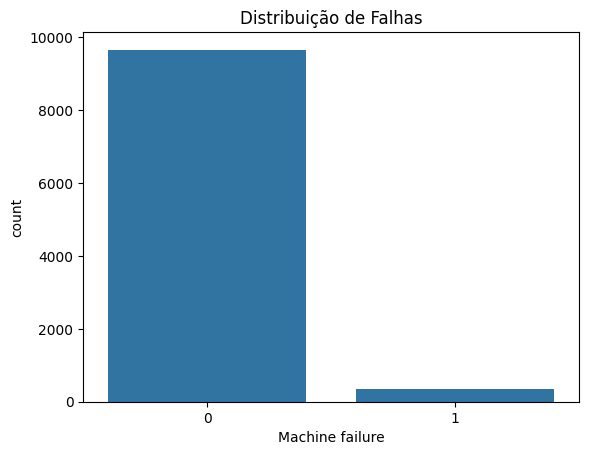

In [ ]:
df['Machine failure'].value_counts()

sns.countplot(x='Machine failure', data=df)
plt.title('Distribuição de Falhas')
plt.show()

Observa-se predominância de registros sem falha em relação às ocorrências de falha da máquina, caracterizando um cenário de desbalanceamento entre as classes.

**CARTAS DE CONTROLE**

O objetivo da carta de controle é monitorar a estabilidade do processo produtivo e identificar possíveis variações anormais nas condições operacionais da usinagem industrial. As cartas foram construídas utilizando a média da variável como linha central e limites de controle calculados com base em três desvios padrão.

- Linha central: representa a média do processo;
- Limite Superior de Controle (LSC): representa o limite máximo esperado para a variabilidade natural do processo;
- Limite Inferior de Controle (LIC): representa o limite mínimo esperado para a variabilidade natural do processo.

Observações fora desses limites podem indicar a presença de causas especiais de variação, sugerindo possíveis instabilidades operacionais, desgaste do sistema ou condições associadas a falhas da máquina. Além dos pontos fora de controle, também são analisados padrões de tendência, dispersão e comportamento das variáveis ao longo das amostras.

***Carta de controle - Torque***

A variável Torque representa o esforço mecânico aplicado durante o processo de usinagem industrial. O monitoramento do torque é relevante porque aumentos excessivos de carga mecânica podem indicar alterações operacionais, desgaste da ferramenta ou condições inadequadas de funcionamento do sistema.

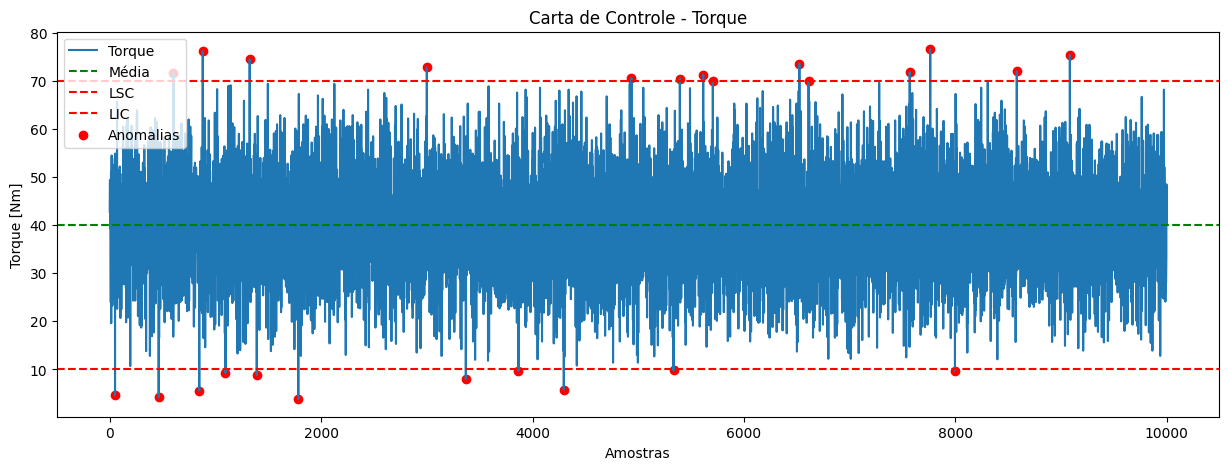

,count
Machine failure,
1,24
0,1


In [ ]:
media = df['Torque [Nm]'].mean()
desvio = df['Torque [Nm]'].std()
LSC = media + 3*desvio
LIC = media - 3*desvio

plt.figure(figsize=(15,5))
plt.plot(df['Torque [Nm]'], label='Torque')
plt.axhline(media, color='green', linestyle='--', label='Média')
plt.axhline(LSC, color='red', linestyle='--', label='LSC')
plt.axhline(LIC, color='red', linestyle='--', label='LIC')
anomalias = df[
    (df['Torque [Nm]'] > LSC) |
    (df['Torque [Nm]'] < LIC)
]
plt.scatter(
    anomalias.index,
    anomalias['Torque [Nm]'],
    color='red',
    label='Anomalias'
)
plt.title('Carta de Controle - Torque')
plt.xlabel('Amostras')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.show()

anomalias[['Torque [Nm]', 'Machine failure']]
anomalias['Machine failure'].value_counts()
anomalias = df[
    (df['Torque [Nm]'] > LSC) |
    (df['Torque [Nm]'] < LIC)
]
anomalias['Machine failure'].value_counts()

Observa-se que parte das amostras ultrapassou os limites estatísticos de controle estabelecidos para o processo. Ao analisar os pontos identificados como fora de controle, observa-se que parte dessas ocorrências coincide com registros de falha da máquina. Esse comportamento sugere que desvios significativos nas variáveis operacionais podem estar relacionados ao surgimento de falhas no processo produtivo, como a mudanças nas condições de usinagem, sobrecarga operacional ou degradação progressiva dos componentes do sistema, reforçando a importância do monitoramento estatístico contínuo.

Além da presença de anomalias pontuais, observa-se elevada variabilidade nas medições operacionais, indicando instabilidade estatística do processo. Altos níveis de dispersão podem comprometer a previsibilidade operacional e aumentar a probabilidade de ocorrência de falhas ou perda de qualidade no processo produtivo.

***Carta de controle - Desgaste da ferramenta***

A variável Tool wear representa o nível de desgaste acumulado da ferramenta de usinagem ao longo da operação industrial. O monitoramento dessa variável é relevante pois níveis elevados de desgaste podem impactar diretamente a qualidade do produto, aumentar esforços mecânicos e elevar a probabilidade de falhas operacionais.

(0, 14)


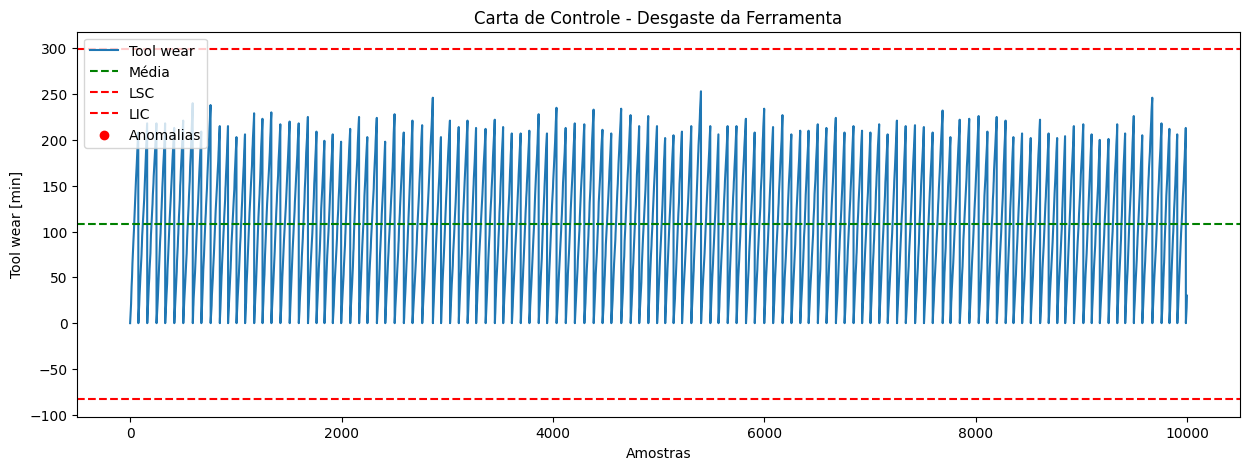

,count
Machine failure,


In [ ]:
media_tool = df['Tool wear [min]'].mean()
desvio_tool = df['Tool wear [min]'].std()
LSC_tool = media_tool + 3*desvio_tool
LIC_tool = media_tool - 3*desvio_tool

anomalias_tool = df[
    (df['Tool wear [min]'] > LSC_tool) |
    (df['Tool wear [min]'] < LIC_tool)
]
print(anomalias_tool.shape)

plt.figure(figsize=(15,5))
plt.plot(df['Tool wear [min]'],
         label='Tool wear')
plt.axhline(media_tool,
            color='green',
            linestyle='--',
            label='Média')
plt.axhline(LSC_tool,
            color='red',
            linestyle='--',
            label='LSC')
plt.axhline(LIC_tool,
            color='red',
            linestyle='--',
            label='LIC')
plt.scatter(
    anomalias_tool.index,
    anomalias_tool['Tool wear [min]'],
    color='red',
    label='Anomalias'
)
plt.title('Carta de Controle - Desgaste da Ferramenta')
plt.xlabel('Amostras')
plt.ylabel('Tool wear [min]')
plt.legend()
plt.show()

anomalias_tool['Machine failure'].value_counts()

Observa-se a presença de pontos próximos dos limites de controle, indicando possíveis condições operacionais associadas à degradação progressiva da ferramenta.

Além das anomalias pontuais, nota-se tendência gradual de crescimento da variável em determinados intervalos, comportamento compatível com processos de desgaste contínuo em operações de usinagem industrial. Esse padrão sugere redução progressiva da estabilidade operacional, podendo impactar diretamente a qualidade do processo e aumentar o risco de falhas mecânicas.

***Carta de Controle - velocidade de rotação***

A variável Rotational speed representa a velocidade de rotação do equipamento durante o processo produtivo. A estabilidade dessa variável é importante para garantir condições adequadas de usinagem, pois oscilações excessivas podem comprometer a qualidade operacional e gerar esforços mecânicos adicionais no sistema.

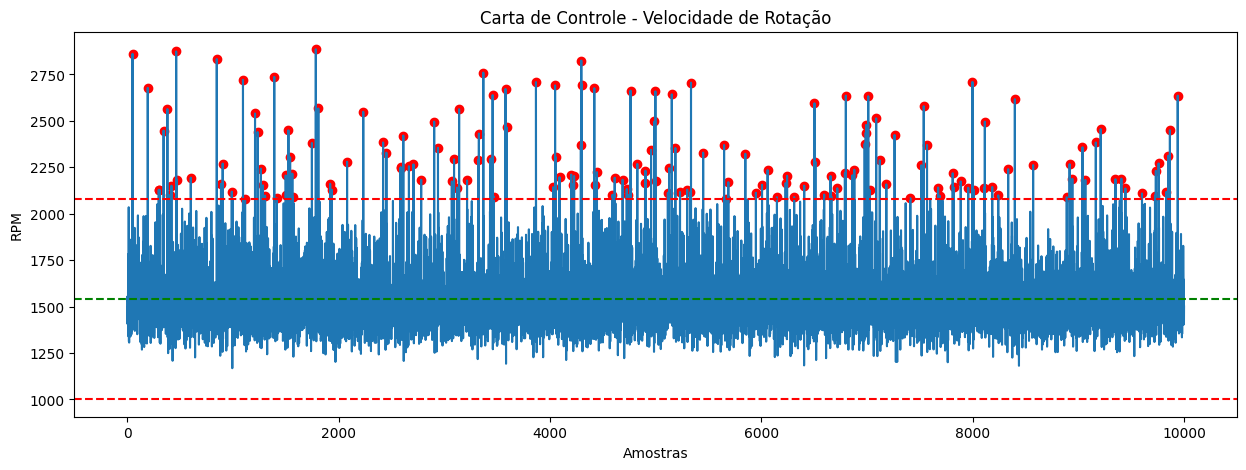

In [ ]:
media_rot = df['Rotational speed [rpm]'].mean()
desvio_rot = df['Rotational speed [rpm]'].std()
LSC_rot = media_rot + 3*desvio_rot
LIC_rot = media_rot - 3*desvio_rot

anomalias_rot = df[
    (df['Rotational speed [rpm]'] > LSC_rot) |
    (df['Rotational speed [rpm]'] < LIC_rot)
]

plt.figure(figsize=(15,5))
plt.plot(df['Rotational speed [rpm]'])
plt.axhline(media_rot,
            color='green',
            linestyle='--')
plt.axhline(LSC_rot,
            color='red',
            linestyle='--')
plt.axhline(LIC_rot,
            color='red',
            linestyle='--')
plt.scatter(
    anomalias_rot.index,
    anomalias_rot['Rotational speed [rpm]'],
    color='red'
)
plt.title('Carta de Controle - Velocidade de Rotação')
plt.xlabel('Amostras')
plt.ylabel('RPM')
plt.show()

A análise da velocidade rotacional evidencia oscilações operacionais ao longo do processo produtivo. Embora grande parte das observações permaneça dentro dos limites estatísticos de controle, observa-se presença de dispersões relevantes e pontos extremos, indicando possíveis instabilidades operacionais.

Em processos industriais de usinagem, variações excessivas de velocidade podem alterar as condições de corte, aumentar vibrações mecânicas e impactar negativamente a estabilidade do sistema produtivo.

***Carta de controle - Tempetratura do Processo***

A variável Process temperature representa a temperatura operacional do processo produtivo durante a usinagem. O monitoramento dessa variável é importante porque aumentos excessivos de temperatura podem indicar sobrecarga operacional, atrito elevado ou condições inadequadas de funcionamento do equipamento.

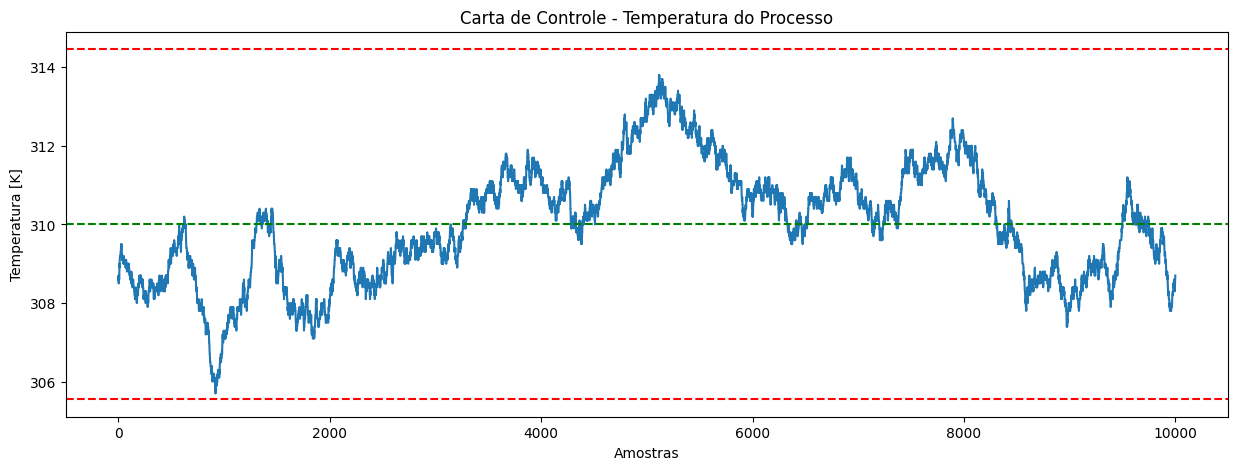

In [ ]:
media_temp = df['Process temperature [K]'].mean()
desvio_temp = df['Process temperature [K]'].std()
LSC_temp = media_temp + 3*desvio_temp
LIC_temp = media_temp - 3*desvio_temp

anomalias_temp = df[
    (df['Process temperature [K]'] > LSC_temp) |
    (df['Process temperature [K]'] < LIC_temp)
]

plt.figure(figsize=(15,5))
plt.plot(df['Process temperature [K]'])
plt.axhline(media_temp,
            color='green',
            linestyle='--')
plt.axhline(LSC_temp,
            color='red',
            linestyle='--')
plt.axhline(LIC_temp,
            color='red',
            linestyle='--')
plt.scatter(
    anomalias_temp.index,
    anomalias_temp['Process temperature [K]'],
    color='red'
)
plt.title('Carta de Controle - Temperatura do Processo')
plt.xlabel('Amostras')
plt.ylabel('Temperatura [K]')
plt.show()

A carta de controle da temperatura do processo evidencia comportamento relativamente variável associado a possíveis condições anormais de operação.

Variações significativas de temperatura podem indicar aumento de atrito mecânico, sobrecarga do sistema ou alterações nas condições de usinagem. Além disso, desvios térmicos podem contribuir para degradação do equipamento e redução da confiabilidade operacional do processo produtivo.

A análise conjunta das cartas de controle indica que o processo produtivo não apresenta estabilidade estatística completamente uniforme ao longo das observações analisadas.

Embora parte significativa das amostras permaneça dentro dos limites de controle, observam-se regiões com elevada variabilidade operacional, presença de pontos extremos e tendências associadas à degradação progressiva de determinadas variáveis operacionais.

Esses comportamentos sugerem a ocorrência de causas especiais de variação, indicando possíveis alterações nas condições de usinagem, desgaste acumulado da ferramenta e mudanças no esforço operacional do sistema produtivo.

***Fazendo o heatmap de correlação***

Foi elaborada uma matriz de correlação entre as variáveis numéricas do processo produtivo. O objetivo foi identificar relações entre as variáveis operacionais e possíveis associações com as falhas da máquina.

<Axes: >

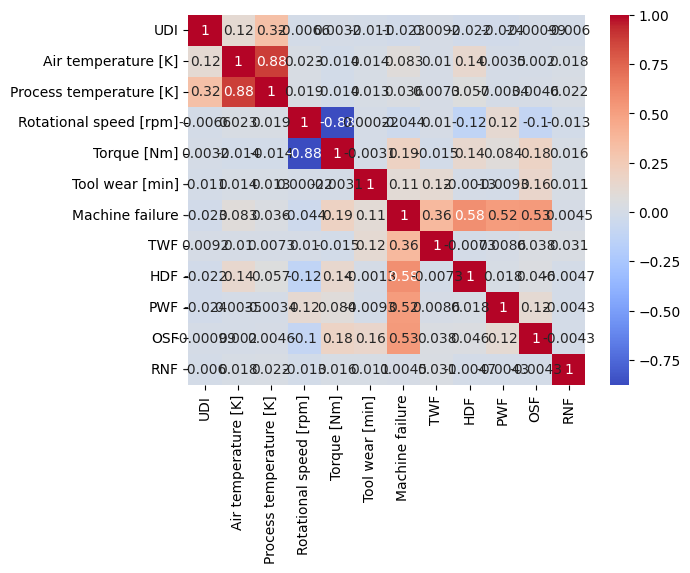

In [ ]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

Observou-se que algumas variáveis apresentam associação moderada com a ocorrência de falhas da máquina, indicando potencial relevância para aplicações preditivas.

Além disso, a análise evidencia possíveis relações entre desgaste da ferramenta, torque e comportamento operacional do equipamento, fatores frequentemente associados à degradação do processo produtivo.

**PREPARAÇÃO DOS DADOS**



Após a análise exploratória inicial, foi realizada a etapa de preparação dos dados com o objetivo de garantir a consistência das informações utilizadas no modelo.

Inicialmente, verificou-se que o dataset não apresenta valores ausentes, o que indica boa qualidade dos dados coletados.

***Tratamento de Outliers***

Optou-se por não remover outliers nesta etapa, pois valores extremos podem representar condições reais de operação crítica do processo produtivo, sendo relevantes para a análise de falhas e para o desenvolvimento do modelo preditivo.


***Normalização dos Dados***

Não foi aplicada normalização nas variáveis, pois o modelo Random Forest não é sensível à escala dos dados.

***Machine Learning***

Além da análise estatística, foi desenvolvido um modelo de Machine Learning com o objetivo de identificar padrões operacionais associados à ocorrência de falhas da máquina. A utilização de técnicas preditivas permite complementar a análise estatística tradicional, possibilitando detectar comportamentos anormais do processo produtivo e apoiar estratégias de manutenção preditiva e monitoramento contínuo da qualidade industrial.


Foram selecionadas as principais variáveis operacionais do processo produtivo como entradas do modelo preditivo, enquanto a variável "Machine failure" foi utilizada como variável alvo para classificação das falhas.

In [ ]:
X = df[['Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]']]

y = df['Machine failure']

***Separando treino e teste***

Os dados foram divididos em conjuntos de treino e teste, utilizando 70% das observações para treinamento do modelo e 30% para validação. A utilização do parâmetro stratify permitiu preservar a proporção original entre registros com e sem falha, reduzindo impactos do desbalanceamento durante a avaliação do modelo.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


**MODELO BASELINE (REGRESSÃO LOGÍSTICA)**

Como forma de comparação inicial, foi utilizado um modelo simples de regressão logística.

O objetivo do modelo baseline é servir como referência para avaliar se o modelo principal (Random Forest) apresenta melhoria significativa de desempenho.

A regressão logística é um modelo linear amplamente utilizado em problemas de classificação binária, sendo uma referência inicial importante em análises preditivas.

A comparação entre o modelo baseline e o modelo mais complexo permite verificar o ganho de desempenho obtido com técnicas mais avançadas.


In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_baseline = LogisticRegression(max_iter=1000)
modelo_baseline.fit(X_train, y_train)

pred_baseline = modelo_baseline.predict(X_test)

print("Baseline - Regressão Logística")
print(confusion_matrix(y_test, pred_baseline))
print(classification_report(y_test, pred_baseline))

Baseline - Regressão Logística
[[2889    9]
 [  83   19]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2898
           1       0.68      0.19      0.29       102

    accuracy                           0.97      3000
   macro avg       0.83      0.59      0.64      3000
weighted avg       0.96      0.97      0.96      3000



**MODELO PRINCIPAL (RANDOM FOREST)**

Para a construção do modelo preditivo foi utilizado o algoritmo Random Forest, amplamente empregado em problemas de classificação em contexto industrial.

O Random Forest é um modelo baseado em múltiplas árvores de decisão, capaz de capturar relações não lineares entre as variáveis e identificar padrões complexos no comportamento do processo produtivo.

A escolha do Random Forest se deve aos seguintes fatores:

- Capacidade de lidar com dados não lineares  
- Robustez a ruídos e outliers  
- Boa performance em dados tabulares  
- Facilidade de interpretação das variáveis mais importantes  

Como alternativa, poderia ser utilizado um modelo mais simples, como a regressão logística, porém o Random Forest apresenta maior capacidade de capturar a complexidade do processo de usinagem.

Além da avaliação da qualidade preditiva, também foi analisado o tempo necessário para treinamento do modelo.

In [ ]:
import time

modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

inicio = time.time()

modelo.fit(X_train, y_train)

fim = time.time()

print(
    "Tempo de treinamento:",
    round(fim - inicio, 4),
    "segundos"
)

Tempo de treinamento: 0.8124 segundos


O dataset apresentava desbalanceamento entre as classes, com maior quantidade de registros sem falha em relação às ocorrências de falha.

Para mitigar esse problema, foi utilizado o parâmetro `class_weight='balanced'` no modelo Random Forest, permitindo que o algoritmo atribua maior peso à classe minoritária durante o treinamento.

Essa abordagem contribui para melhorar a capacidade do modelo em detectar falhas, reduzindo a ocorrência de falsos negativos.

O treinamento do modelo Random Forest foi realizado em aproximadamente **0,81** segundos, indicando baixo custo computacional para a construção do modelo.

Esse resultado demonstra que a abordagem utilizada possui potencial para aplicação em ambientes industriais, nos quais atualizações periódicas do modelo podem ser necessárias para acompanhar mudanças nas condições operacionais do processo produtivo.


***Otimização de Hiperparâmetros***

Embora o modelo Random Forest apresente bom desempenho utilizando parâmetros previamente definidos, é possível melhorar sua capacidade preditiva por meio da otimização dos hiperparâmetros.

Para essa finalidade foi utilizada a técnica Grid Search, que realiza uma busca sistemática por diferentes combinações de parâmetros e seleciona aquela que apresenta melhor desempenho durante a validação cruzada.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)

print("Melhor F1-score:")
print(grid.best_score_)

Melhores parâmetros:
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Melhor F1-score:
0.6439153439153439


A busca pelos hiperparâmetros permitiu identificar a configuração que apresentou melhor desempenho durante o processo de validação.

Os melhores parâmetros encontrados foram:

- Profundidade máxima das árvores (max_depth): 15
- Número de árvores (n_estimators): 200
- Número mínimo de amostras para divisão dos nós (min_samples_split): 5

Com essa configuração foi obtido um F1-score médio de aproximadamente 0,644, indicando bom equilíbrio entre precisão e recall durante a etapa de seleção do modelo.

Os resultados demonstram que a otimização dos hiperparâmetros contribuiu para melhorar a capacidade preditiva do algoritmo e reduzir a dependência de configurações definidas arbitrariamente.

***Modelo otimizado***

Após a identificação dos melhores hiperparâmetros, foi realizado o treinamento de uma nova versão do Random Forest utilizando a configuração considerada mais adequada.

O objetivo dessa etapa é verificar se a otimização proporciona melhorias na capacidade de identificação das falhas operacionais.

In [ ]:
modelo_otimizado = grid.best_estimator_

modelo_otimizado.fit(
    X_train,
    y_train
)

pred_otimizado = modelo_otimizado.predict(
    X_test
)

print(confusion_matrix(
    y_test,
    pred_otimizado
))

print(classification_report(
    y_test,
    pred_otimizado
))

[[2883   15]
 [  42   60]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2898
           1       0.80      0.59      0.68       102

    accuracy                           0.98      3000
   macro avg       0.89      0.79      0.83      3000
weighted avg       0.98      0.98      0.98      3000



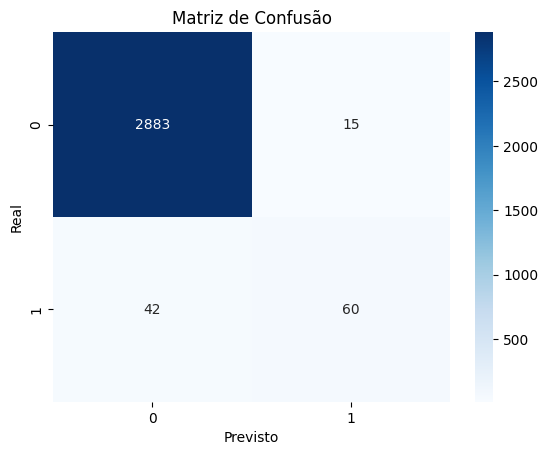

In [ ]:
cm = confusion_matrix(y_test, pred_otimizado)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

A matriz de confusão indicou:

- 2883 observações corretamente classificadas como operação normal;
- 60 falhas corretamente identificadas;
- 15 falsos positivos;
- 42 falsos negativos.

A precisão para a classe de falha atingiu aproximadamente **80%**, indicando que a maior parte das falhas previstas pelo modelo corresponde efetivamente a falhas reais.

O recall foi de aproximadamente **59%**, demonstrando que o modelo consegue identificar mais da metade das falhas existentes na base de teste.

O F1-score da classe de falha foi de aproximadamente **0,68**, representando melhora em relação ao modelo anteriormente utilizado e evidenciando maior equilíbrio entre precisão e capacidade de detecção.

Em aplicações industriais, esse resultado é relevante porque permite identificar falhas potenciais com menor quantidade de alarmes incorretos, contribuindo para ações preventivas mais eficientes.

***Validação Cruzada***

Foi realizada uma validação cruzada com o objetivo de avaliar a estabilidade do modelo em diferentes subconjuntos dos dados.

Foi utilizado o método Stratified K-Fold, que preserva a proporção entre registros com falha e sem falha em cada divisão da base, característica especialmente importante devido ao desbalanceamento existente entre as classes.

A métrica utilizada foi o F1-score, por representar o equilíbrio entre precisão e recall.

In [ ]:
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

scores = cross_val_score(
    modelo_otimizado,
    X,
    y,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring='f1'
)

print(
    "F1-score médio:",
    scores.mean()
)

print(
    "F1-score por fold:",
    scores
)

F1-score médio: 0.6998507440689259
F1-score por fold: [0.74380165 0.75213675 0.66666667 0.688      0.64864865]


O modelo apresentou F1-score médio de aproximadamente **0,70**, indicando desempenho consistente na identificação das falhas ao longo das diferentes amostras avaliadas.

Observa-se baixa variação entre os valores obtidos em cada fold, sugerindo boa estabilidade do modelo e reduzida dependência de uma única divisão dos dados.

Esse comportamento indica que o algoritmo apresenta capacidade satisfatória de generalização, mantendo desempenho relativamente consistente mesmo quando treinado e avaliado em diferentes subconjuntos da base.

Os resultados reforçam a confiabilidade da solução proposta para aplicações de monitoramento e detecção de falhas em processos industriais.

***Previsões***

Além da classificação das observações, o modelo também foi utilizado para estimar probabilidades associadas à ocorrência de falhas.

In [ ]:
pred = modelo_otimizado.predict(X_test)
probabilidades = modelo_otimizado.predict_proba(X_test)
prob_falha = probabilidades[:,1]

resultado_prob = pd.DataFrame({
    'Probabilidade de falha': prob_falha
})
resultado_prob.head(10)

resultado_prob['Probabilidade de falha (%)'] = (
    resultado_prob['Probabilidade de falha'] * 100
)
resultado_prob.head(10)

def classificar_risco(prob):
    if prob < 0.2:
        return 'Baixo risco'
    elif prob < 0.5:
        return 'Médio risco'
    else:
        return 'Alto risco'
resultado_prob['Nível de risco'] = (
    resultado_prob['Probabilidade de falha']
    .apply(classificar_risco)
)
resultado_prob.head(10)

,Probabilidade de falha,Probabilidade de falha (%),Nível de risco
0,0.000000,0.000000,Baixo risco
1,0.000000,0.000000,Baixo risco
2,0.038289,3.828916,Baixo risco
3,0.033045,3.304524,Baixo risco
4,0.000000,0.000000,Baixo risco
5,0.000000,0.000000,Baixo risco
6,0.732120,73.212040,Alto risco
7,0.000000,0.000000,Baixo risco
8,0.000000,0.000000,Baixo risco
9,0.000000,0.000000,Baixo risco


Observa-se que parte das amostras apresentou baixa probabilidade de falha, indicando comportamento compatível com condições normais de operação. Entretanto, algumas observações apresentaram probabilidades significativamente mais elevadas, sugerindo possíveis condições de degradação operacional ou maior risco de falha da máquina.

No contexto industrial, esse tipo de análise possui elevada relevância para aplicações de manutenção preditiva, pois permite priorizar intervenções em condições operacionais consideradas mais críticas antes da ocorrência de falhas efetivas.

In [ ]:
resultado_prob.sort_values(
    by='Probabilidade de falha (%)',
    ascending=False
).head(10)

,Probabilidade de falha,Probabilidade de falha (%),Nível de risco
682,0.959076,95.907598,Alto risco
961,0.948981,94.898114,Alto risco
2835,0.948070,94.807037,Alto risco
2661,0.931552,93.155209,Alto risco
439,0.928091,92.809093,Alto risco
531,0.927396,92.739599,Alto risco
2279,0.916890,91.689044,Alto risco
2697,0.907028,90.702845,Alto risco
1600,0.879917,87.991668,Alto risco
1457,0.870466,87.046629,Alto risco


Observa-se que observações associadas a maiores probabilidades de falha frequentemente coincidem com comportamentos anormais previamente identificados nas cartas de controle, especialmente em variáveis relacionadas ao torque e desgaste da ferramenta. Esse comportamento reforça a relação entre instabilidade operacional e aumento do risco de falhas no processo produtivo.

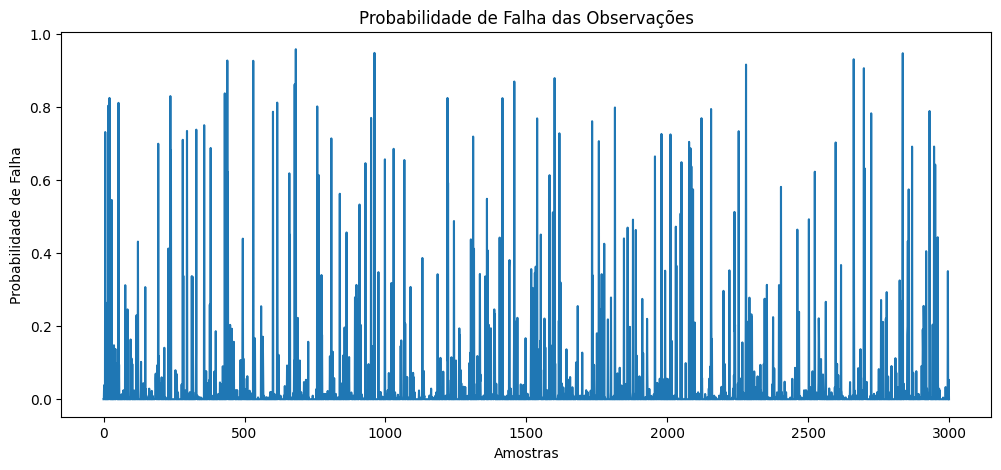

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(prob_falha)

plt.title('Probabilidade de Falha das Observações')
plt.xlabel('Amostras')
plt.ylabel('Probabilidade de Falha')

plt.show()

A análise gráfica das probabilidades previstas evidencia que o modelo atribui níveis distintos de risco às condições operacionais observadas.

Enquanto grande parte das amostras apresenta baixa probabilidade de falha, determinadas observações concentram valores significativamente mais elevados, indicando possíveis condições críticas de operação.

***Overfiting***

O overfitting ocorre quando o modelo aprende excessivamente os padrões presentes nos dados de treinamento, apresentando desempenho elevado nessa base, mas desempenho inferior quando aplicado a dados não vistos.

Para essa análise foram comparadas as métricas obtidas nas bases de treinamento e teste.

In [ ]:
acc_train = modelo_otimizado.score(
    X_train,
    y_train
)

acc_test = modelo_otimizado.score(
    X_test,
    y_test
)

print(
    "Acurácia treino:",
    acc_train
)

print(
    "Acurácia teste:",
    acc_test
)

Acurácia treino: 0.9994285714285714
Acurácia teste: 0.981


Foi obtida acurácia de aproximadamente **99,94%** na base de treinamento e **98,10%** na base de teste.

A pequena diferença observada entre os resultados indica que o modelo apresenta boa capacidade de generalização, mantendo desempenho elevado mesmo quando aplicado a dados não utilizados durante o treinamento.

Dessa forma, não foram identificadas evidências significativas de overfitting, sugerindo que o modelo foi capaz de aprender padrões relevantes do processo produtivo sem memorizar excessivamente os dados de treinamento.

***Comparação entre Modelos***

Ao comparar os resultados do modelo baseline com o modelo Random Forest, observa-se que o Random Forest apresenta melhor capacidade de captura dos padrões associados às falhas do processo.

Isso se deve à sua capacidade de modelar relações não lineares e interações complexas entre as variáveis operacionais.

Dessa forma, o Random Forest se mostra mais adequado para o problema proposto, especialmente considerando a natureza do processo industrial analisado.

***Análise das variáveis***

A análise de importância das variáveis permitiu identificar quais fatores operacionais possuem maior influência na previsão de falhas da máquina.

                  Variável  Importância
3              Torque [Nm]     0.336860
2   Rotational speed [rpm]     0.300425
4          Tool wear [min]     0.215836
0      Air temperature [K]     0.089315
1  Process temperature [K]     0.057564


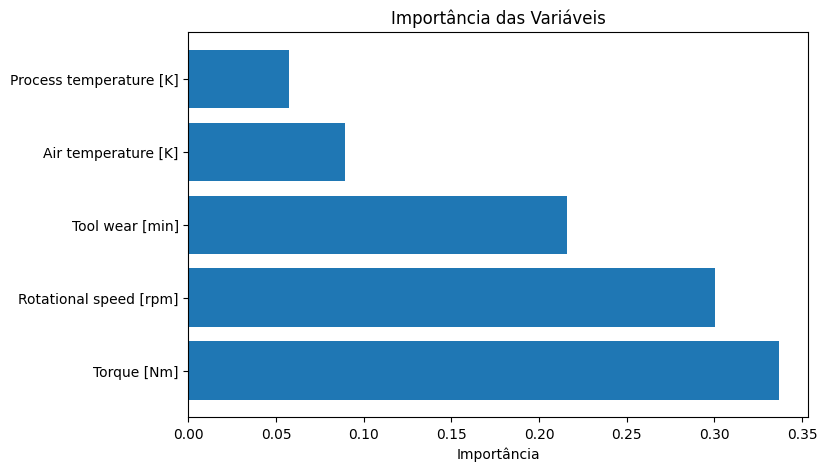

In [ ]:
importances = modelo.feature_importances_
importancia_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importances
})
importancia_df = importancia_df.sort_values(
    by='Importância',
    ascending=False
)
print(importancia_df)


plt.figure(figsize=(8,5))
plt.barh(
    importancia_df['Variável'],
    importancia_df['Importância']
)
plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.show()

Observa-se que variáveis relacionadas ao esforço mecânico, desgaste operacional e condições térmicas apresentam maior relevância no comportamento preditivo do modelo.

Esses resultados reforçam a relação entre degradação operacional e ocorrência de falhas industriais, além de indicar quais parâmetros podem ser priorizados em estratégias de monitoramento contínuo do processo produtivo.

***Recursos computacionais utilizados***

As análises foram desenvolvidas utilizando a linguagem Python no ambiente Google Colab.

Foram empregadas bibliotecas amplamente utilizadas em Ciência de Dados e Aprendizado de Máquina, incluindo Pandas, NumPy, Matplotlib, Seaborn e Scikit-Learn.

Os experimentos foram executados utilizando os recursos computacionais disponibilizados pela plataforma Google Colab, com processamento realizado em CPU.

Além disso, foram aplicadas técnicas de validação cruzada, otimização de hiperparâmetros e avaliação estatística para garantir maior confiabilidade aos resultados obtidos.

**CONCLUSÃO E RECOMENDAÇÕES**

A análise realizada permitiu avaliar o comportamento do processo de usinagem a partir de duas abordagens complementares: o Controle Estatístico de Processos (CEP) e o Machine Learning.

As cartas de controle evidenciaram a presença de variações operacionais, pontos fora dos limites de controle e tendências associadas à degradação do processo, indicando que o sistema não opera de forma totalmente estável.

O modelo de Machine Learning demonstrou boa capacidade de identificação de padrões associados às falhas, destacando a relevância de variáveis como torque, velocidade rotacional e desgaste da ferramenta.

***Recomendações***

- Implementar monitoramento contínuo do processo por meio de cartas de controle  
- Priorizar o acompanhamento das variáveis mais críticas identificadas  
- Utilizar modelos preditivos como apoio à manutenção preventiva  
- Melhorar o modelo para aumentar o recall e reduzir falhas não detectadas  

***Conclusão Geral***

A integração entre técnicas estatísticas e modelos preditivos mostrou-se eficaz para a análise da qualidade do processo produtivo, contribuindo para a identificação de falhas e para a melhoria contínua das operações industriais.